In [13]:
import pandas as pd
import numpy as np

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [14]:
url = "https://raw.githubusercontent.com/dphi-official/Datasets/master/Loan_Data/loan_train.csv"
df = pd.read_csv(url)

In [15]:
print(df.head())

print(df.isnull().sum())

   Unnamed: 0   Loan_ID  Gender Married Dependents     Education  \
0           0  LP002305  Female      No          0      Graduate   
1           1  LP001715    Male     Yes         3+  Not Graduate   
2           2  LP002086  Female     Yes          0      Graduate   
3           3  LP001136    Male     Yes          0  Not Graduate   
4           4  LP002529    Male     Yes          2      Graduate   

  Self_Employed  ApplicantIncome  CoapplicantIncome  LoanAmount  \
0            No             4547                0.0       115.0   
1           Yes             5703                0.0       130.0   
2            No             4333             2451.0       110.0   
3           Yes             4695                0.0        96.0   
4            No             6700             1750.0       230.0   

   Loan_Amount_Term  Credit_History Property_Area  Loan_Status  
0             360.0             1.0     Semiurban            1  
1             360.0             1.0         Rural         

In [16]:
for col in df.columns:
    if df[col].dtype == "object":
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        df[col].fillna(df[col].median(), inplace=True)

/tmp/ipykernel_6837/3563149562.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_6837/3563149562.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

In [17]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = le.fit_transform(df[col])

In [18]:
X = df.drop("Loan_Status", axis=1)
y = df["Loan_Status"]

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [20]:
model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=4,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

In [21]:
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [22]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8080808080808081


In [23]:
print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))


Confusion Matrix
[[17 17]
 [ 2 63]]

Classification Report
              precision    recall  f1-score   support

           0       0.89      0.50      0.64        34
           1       0.79      0.97      0.87        65

    accuracy                           0.81        99
   macro avg       0.84      0.73      0.76        99
weighted avg       0.82      0.81      0.79        99



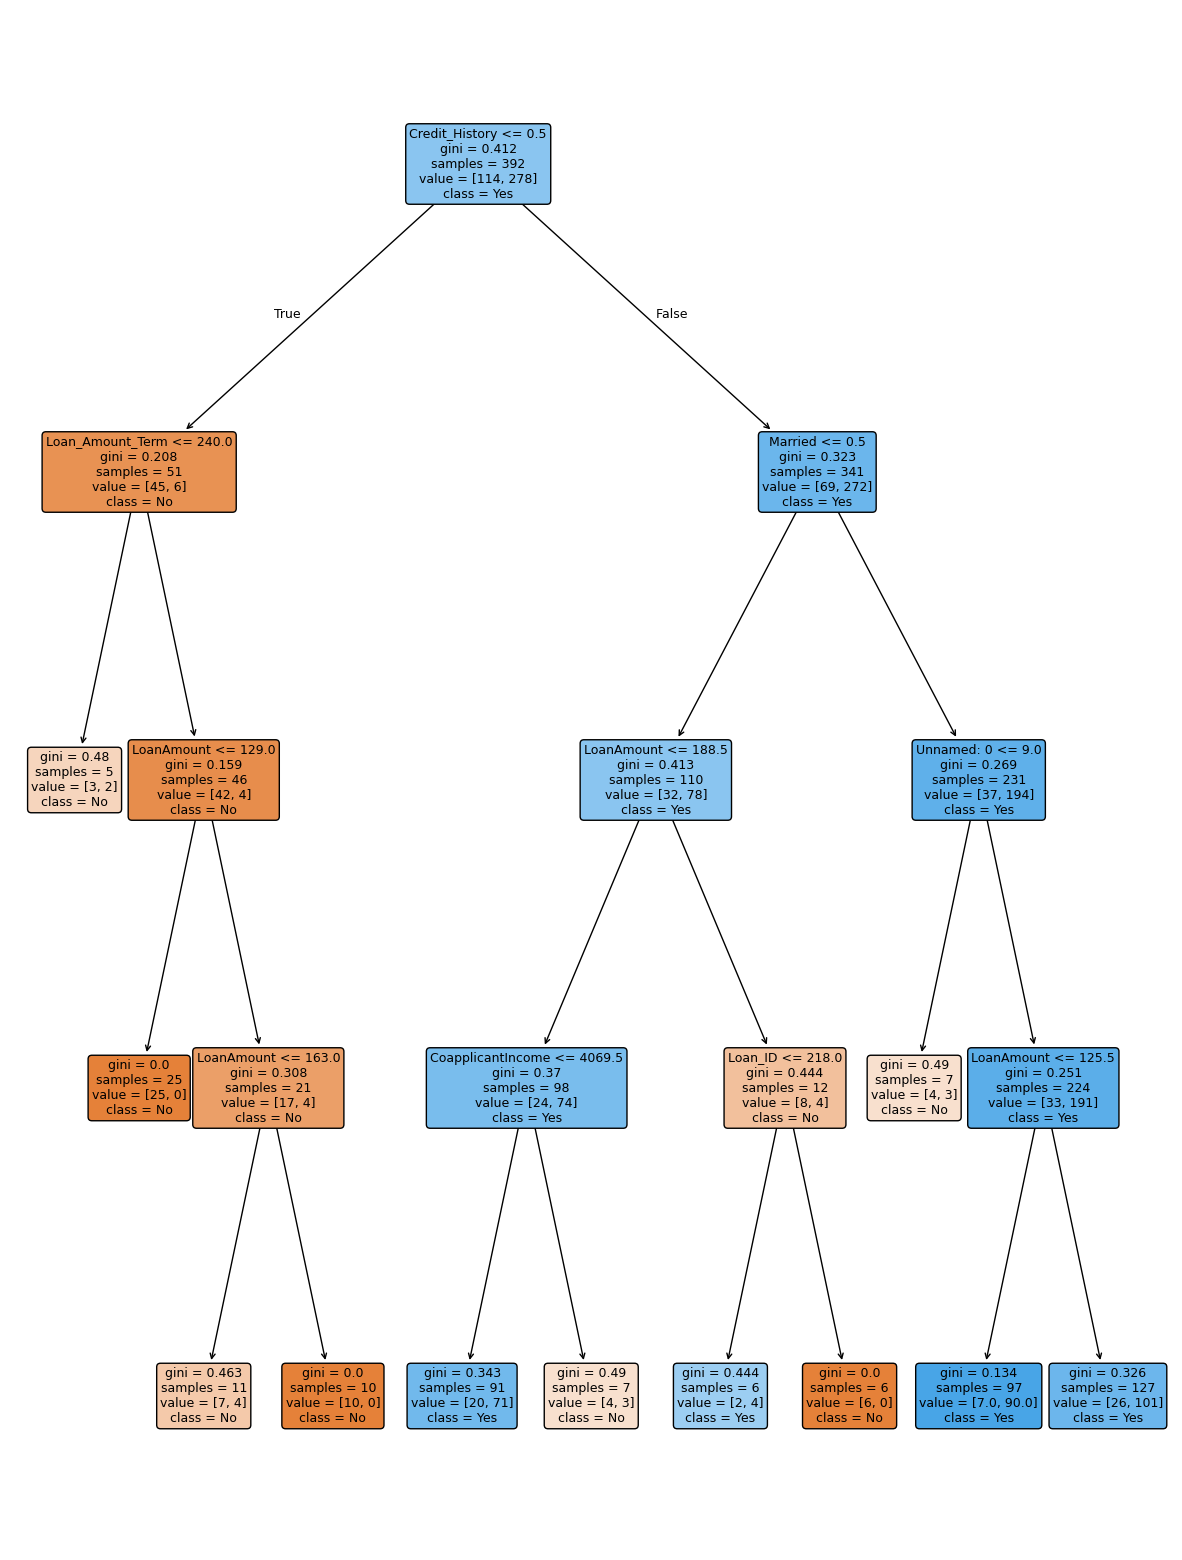

In [24]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(15,20))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["No", "Yes"],
    filled=True,
    rounded=True,
    fontsize=9
)

plt.show()